# Kenya Schools Analysis - Finding Schools That Need Help

**What we're doing:** Looking at school data to find which schools need the most help (teachers, toilets, classrooms)

**Goal:** Help government and NGOs know where to send aid first

## 1. Getting Started

In [ ]:
# Load the tools we need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Libraries loaded!")

Tools loaded!


In [2]:
# Load the school data
schools = pd.read_csv('EduMap_FINAL.csv')

print(f"Loaded data for {len(schools):,} schools")
print(f"Data has {len(schools.columns)} columns")
schools.head()

Loaded data for 31,230 schools
Data has 23 columns


,Unnamed: 0.1,Unnamed: 0,School_ID,Name_of_Sc,School_type,Status,SchSponsor,Province,District,Division,...,Total_Students,Students_per_Teacher,Teachers_Required,Extra_Teachers_Required,toilets,expected_toilets,extra_toilets_required,classes,expected_classes,extra_classes_required
0,0,0,10001,CHEBIREBEI PRI,PRIMARY SCHOOL,PUBLIC,RELIGIOUS ORGANIZATION,RIFT VALLEY,KOIBATEK,KISANANA,...,202,22.444444,5.0,0.0,1,7.0,6.0,5,8,3
1,1,1,10002,WASEGES PRI,PRIMARY SCHOOL,PUBLIC,RELIGIOUS ORGANIZATION,RIFT VALLEY,KOIBATEK,KISANANA,...,535,89.166667,13.0,7.0,8,18.0,10.0,6,8,2
2,2,2,10003,KIRIBOT PRI,PRIMARY SCHOOL,PUBLIC,COMMUNITY,RIFT VALLEY,KOIBATEK,KISANANA,...,960,64.000000,24.0,9.0,1,32.0,31.0,7,8,1
3,3,3,10004,KABUSWO PRI SCH,PRIMARY SCHOOL,PUBLIC,COMMUNITY,RIFT VALLEY,KOIBATEK,KISANANA,...,370,28.461538,9.0,0.0,4,13.0,9.0,6,8,2
4,4,4,10005,VONDENI PRI SCHOOL,PRIMARY SCHOOL,PUBLIC,COMMUNITY,EASTERN,MACHAKOS,MASINGA,...,206,20.600000,5.0,0.0,8,7.0,0.0,7,8,1


## 2. Quick Look at the Data

In [3]:
# See what we're working with
print("Basic info about our school data:")
print(f"Total schools: {len(schools):,}")
print(f"Total students: {schools['Total_Students'].sum():,}")
print(f"Total teachers: {schools['Total_Teachers'].sum():,}")
print(f"Average students per teacher: {schools['Students_per_Teacher'].mean():.1f}")

Basic info about our school data:
Total schools: 31,230
Total students: 17,241,891
Total teachers: 280,688
Average students per teacher: 77.6


In [4]:
# Check for missing data
missing = schools.isnull().sum()
print("Missing data:")
print(missing[missing > 0])

Missing data:
Name_of_Sc     1
School_type    1
Status         1
SchSponsor     1
Province       1
District       1
Division       1
Location       1
Costituenc     1
dtype: int64


## 3. Clean Up the Data

In [5]:
# Clean up the data
data = schools.copy()

# Fill missing values
data = data.fillna('Unknown')

print(f"Cleaned data: {len(data)} schools ready for analysis")

Cleaned data: 31230 schools ready for analysis


## 4. Find Schools That Need Help

**Kenya's standard:** 40 students per teacher is the goal

In [6]:
# Kenya's target: 40 students per teacher
TARGET_RATIO = 40

# Find schools with too many students per teacher
overcrowded = data[data['Students_per_Teacher'] > TARGET_RATIO]

print(f"Schools with too many students per teacher: {len(overcrowded):,}")
print(f"That's {len(overcrowded)/len(data)*100:.1f}% of all schools!")
print(f"Average ratio in overcrowded schools: {overcrowded['Students_per_Teacher'].mean():.1f} students per teacher")

Schools with too many students per teacher: 22,236
That's 71.2% of all schools!
Average ratio in overcrowded schools: 98.8 students per teacher


In [7]:
# Show the worst schools (most overcrowded)
worst_schools = data.nlargest(10, 'Students_per_Teacher')[['Name_of_Sc', 'Province', 'Students_per_Teacher', 'Total_Students', 'Total_Teachers']]

print("TOP 10 MOST OVERCROWDED SCHOOLS:")
print(worst_schools)

TOP 10 MOST OVERCROWDED SCHOOLS:
                        Name_of_Sc     Province  Students_per_Teacher  \
6013               ESITETI PRI SCH  RIFT VALLEY            333.333333   
14308          MOIBEN SPECIAL UNIT  RIFT VALLEY            333.333333   
3294                    DZOMBO PRY        COAST            333.000000   
11884             CHESONOI PRI SCH  RIFT VALLEY            333.000000   
21193               ALUNGO PRI SCH       NYANZA            332.666667   
22481  GARDEN ESTATATE ACADEMY PRI      NAIROBI            332.666667   
30609                   IKAASU PRI      EASTERN            332.666667   
651                  TUMOI PRI SCH  RIFT VALLEY            332.333333   
4613         MONORU PRIMARY SCHOOL  RIFT VALLEY            332.333333   
10351             ILLIAGAT PRI SCH  RIFT VALLEY            332.333333   

       Total_Students  Total_Teachers  
6013             1000               3  
14308            1000               3  
3294              999               3  
118

## 5. Teacher Shortage Analysis

In [8]:
# How many extra teachers do we need?
total_teacher_shortage = data['Extra_Teachers_Required'].sum()
schools_needing_teachers = len(data[data['Extra_Teachers_Required'] > 0])

print(f"TEACHER SHORTAGE SUMMARY:")
print(f"Total extra teachers needed: {total_teacher_shortage:,}")
print(f"Schools that need more teachers: {schools_needing_teachers:,}")
print(f"Average teachers needed per school: {total_teacher_shortage/schools_needing_teachers:.1f}")

TEACHER SHORTAGE SUMMARY:
Total extra teachers needed: 189,153.0
Schools that need more teachers: 21,583
Average teachers needed per school: 8.8


In [9]:
# Which provinces need the most teachers?
teacher_need_by_province = data.groupby('Province')['Extra_Teachers_Required'].sum().sort_values(ascending=False)

print("TEACHER SHORTAGE BY PROVINCE:")
for province, shortage in teacher_need_by_province.items():
    print(f"{province}: {shortage:,} teachers")

TEACHER SHORTAGE BY PROVINCE:
EASTERN: 60,721.0 teachers
RIFT VALLEY: 43,808.0 teachers
NYANZA: 29,281.0 teachers
CENTRAL: 18,918.0 teachers
WESTERN: 15,889.0 teachers
COAST: 10,358.0 teachers
NAIROBI: 7,422.0 teachers
NORTH EASTERN: 2,748.0 teachers
Central: 8.0 teachers
Unknown: 0.0 teachers


## 6. Toilet/Sanitation Problems

In [10]:
# Toilet shortage analysis
total_toilet_shortage = data['extra_toilets_required'].sum()
schools_needing_toilets = len(data[data['extra_toilets_required'] > 0])
schools_no_toilets = len(data[data['toilets'] == 0])

print(f"TOILET/SANITATION SUMMARY:")
print(f"Total extra toilets needed: {total_toilet_shortage:,}")
print(f"Schools that need more toilets: {schools_needing_toilets:,}")
print(f"Schools with NO toilets: {schools_no_toilets:,} (URGENT!)")

TOILET/SANITATION SUMMARY:
Total extra toilets needed: 451,203.0
Schools that need more toilets: 29,442
Schools with NO toilets: 0 (URGENT!)


## 7. Classroom Shortage

In [11]:
# Classroom shortage analysis
total_classroom_shortage = data['extra_classes_required'].sum()
schools_needing_classrooms = len(data[data['extra_classes_required'] > 0])

print(f"CLASSROOM SHORTAGE SUMMARY:")
print(f"Total extra classrooms needed: {total_classroom_shortage:,}")
print(f"Schools that need more classrooms: {schools_needing_classrooms:,}")

CLASSROOM SHORTAGE SUMMARY:
Total extra classrooms needed: 26,154
Schools that need more classrooms: 10,432


## 8. Simple Charts to Show the Problems

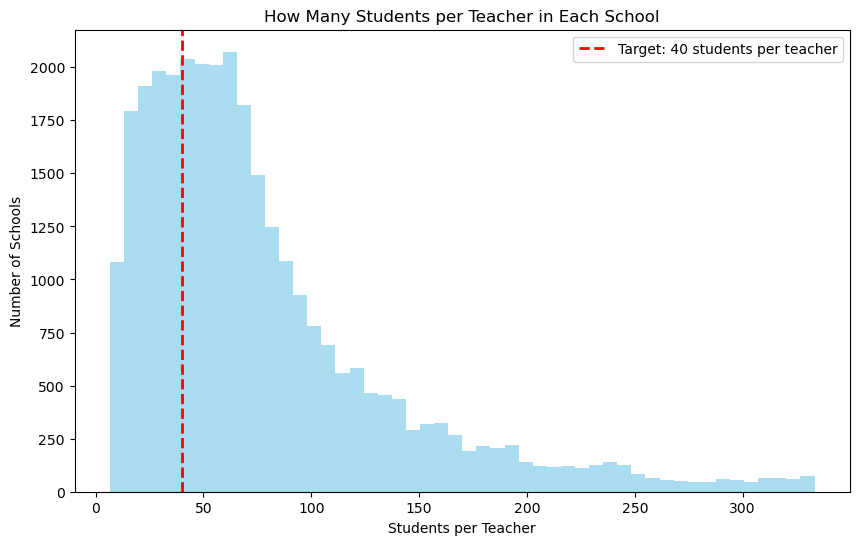

RED LINE = Good target. Schools to the right of the red line need help!


In [12]:
# Chart 1: Student-teacher ratios
plt.figure(figsize=(10, 6))
plt.hist(data['Students_per_Teacher'], bins=50, alpha=0.7, color='skyblue')
plt.axvline(x=40, color='red', linestyle='--', linewidth=2, label='Target: 40 students per teacher')
plt.xlabel('Students per Teacher')
plt.ylabel('Number of Schools')
plt.title('How Many Students per Teacher in Each School')
plt.legend()
plt.show()

print("RED LINE = Good target. Schools to the right of the red line need help!")

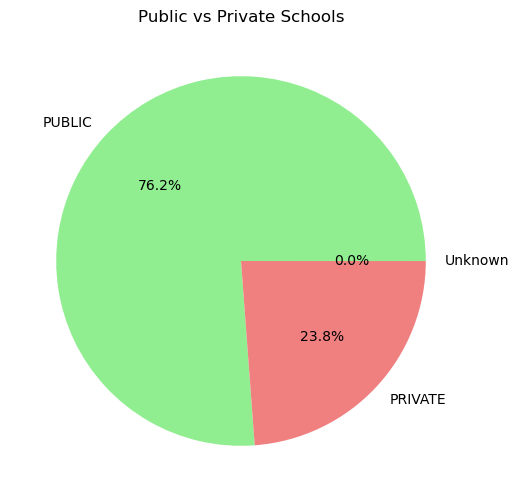

Most schools (23,792) are PUBLIC


In [13]:
# Chart 2: Public vs Private schools
status_counts = data['Status'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', 
        colors=['lightgreen', 'lightcoral'])
plt.title('Public vs Private Schools')
plt.show()

print(f"Most schools ({status_counts.iloc[0]:,}) are {status_counts.index[0]}")

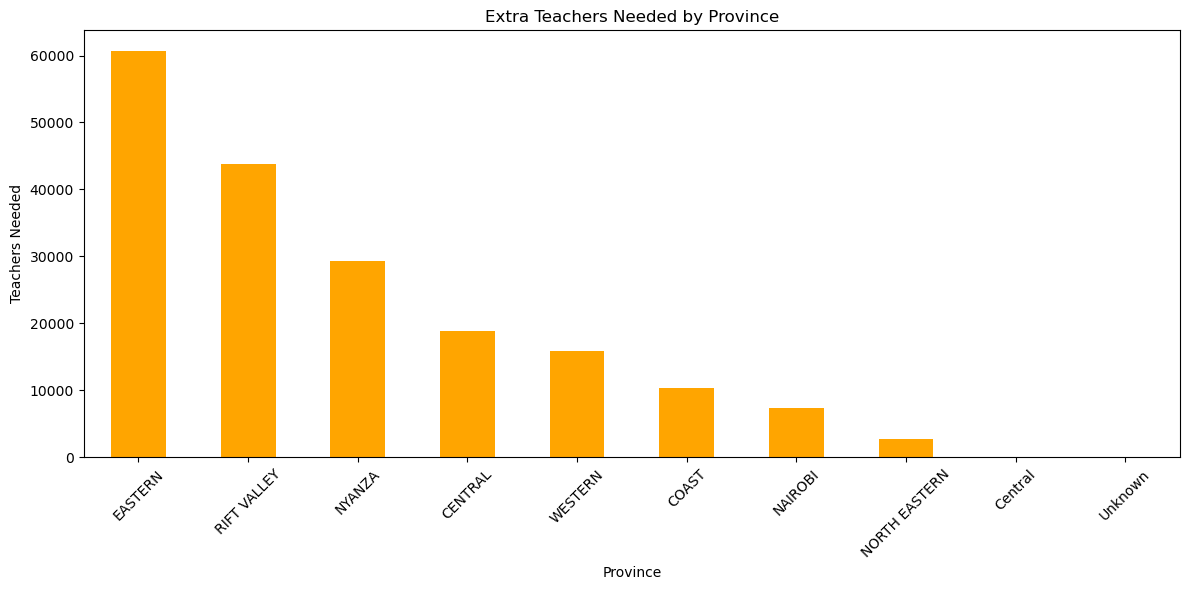

Worst province: EASTERN needs 60,721.0 teachers


In [14]:
# Chart 3: Teacher shortage by province
plt.figure(figsize=(12, 6))
teacher_need_by_province.plot(kind='bar', color='orange')
plt.title('Extra Teachers Needed by Province')
plt.xlabel('Province')
plt.ylabel('Teachers Needed')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Worst province: {teacher_need_by_province.index[0]} needs {teacher_need_by_province.iloc[0]:,} teachers")

# Create a simple priority score (0-100) - EDUCATION FOCUSED
data['priority_score'] = 0

# TEACHERS FIRST - Add points for teacher shortage (0-60 points)
max_teacher_deficit = data['Extra_Teachers_Required'].max()
data['priority_score'] += (data['Extra_Teachers_Required'] / max_teacher_deficit * 60)

# LEARNING ENVIRONMENT - Add points for high student-teacher ratio (0-25 points)
ratio_excess = (data['Students_per_Teacher'] - TARGET_RATIO).clip(lower=0)
max_ratio_excess = ratio_excess.max()
data['priority_score'] += (ratio_excess / max_ratio_excess * 25)

# BASIC SUPPORT - Add points for classroom shortage (0-10 points)
max_class_deficit = data['extra_classes_required'].max()
data['priority_score'] += (data['extra_classes_required'] / max_class_deficit * 10)

# BASIC SUPPORT - Add points for toilet shortage (0-5 points)
max_toilet_deficit = data['extra_toilets_required'].max()
data['priority_score'] += (data['extra_toilets_required'] / max_toilet_deficit * 5)

print(f"Priority scores calculated!")
print(f"Highest priority score: {data['priority_score'].max():.1f}")
print(f"Average priority score: {data['priority_score'].mean():.1f}")
print("FOCUS: Teachers (60%) + Student ratios (25%) + Infrastructure (15%)")

In [15]:
# Create a simple priority score (0-100)
data['priority_score'] = 0

# Add points for teacher shortage (0-40 points)
max_teacher_deficit = data['Extra_Teachers_Required'].max()
data['priority_score'] += (data['Extra_Teachers_Required'] / max_teacher_deficit * 40)

# Add points for high student-teacher ratio (0-30 points)
ratio_excess = (data['Students_per_Teacher'] - TARGET_RATIO).clip(lower=0)
max_ratio_excess = ratio_excess.max()
data['priority_score'] += (ratio_excess / max_ratio_excess * 30)

# Add points for toilet shortage (0-15 points)
max_toilet_deficit = data['extra_toilets_required'].max()
data['priority_score'] += (data['extra_toilets_required'] / max_toilet_deficit * 15)

# Add points for classroom shortage (0-15 points)
max_class_deficit = data['extra_classes_required'].max()
data['priority_score'] += (data['extra_classes_required'] / max_class_deficit * 15)

print(f"Priority scores calculated!")
print(f"Highest priority score: {data['priority_score'].max():.1f}")
print(f"Average priority score: {data['priority_score'].mean():.1f}")

Priority scores calculated!
Highest priority score: 99.9
Average priority score: 25.0


In [16]:
# Show the TOP 20 schools that need help most
priority_schools = data.nlargest(20, 'priority_score')[[
    'Name_of_Sc', 'Province', 'District', 'priority_score', 
    'Students_per_Teacher', 'Extra_Teachers_Required', 
    'extra_toilets_required', 'extra_classes_required'
]]

print("🚨 TOP 20 SCHOOLS THAT NEED HELP MOST:")
print(priority_schools.round(1))

🚨 TOP 20 SCHOOLS THAT NEED HELP MOST:
                   Name_of_Sc     Province     District  priority_score  \
9292    ROKA KIBIBONI PRI SCH        COAST         LAMU            99.9   
11045  CHEPTOROI PRIMARY  SCH  RIFT VALLEY       NAKURU            98.9   
25100        KAMULEWA PRIMARY      EASTERN       MWINGI            98.6   
18660          MOSILY ACADEMY       NYANZA      NYAMIRA            97.9   
7818           KAMUKA PRI SCH      CENTRAL    NYANDARUA            97.6   
17553         NGISIRU PRY SCH       NYANZA        KURIA            97.5   
9621           KANYILILYA PRY      EASTERN      MAKUENI            97.5   
2264         MATATHIA PRI SCH      CENTRAL       KIAMBU            96.8   
13412          KAMARA PRI SCH  RIFT VALLEY       NAKURU            96.8   
14188               BOROR PRI  RIFT VALLEY  UASIN GISHU            96.5   
21528   NYANBASO SPECIAL UNIT       NYANZA      NYAMIRA            96.3   
3294               DZOMBO PRY        COAST        KWALE       

## 10. Key Findings - What We Learned

In [17]:
# Summary of key findings
print("🎯 MAIN FINDINGS:")
print("="*50)

print(f"1. OVERCROWDED SCHOOLS: {len(overcrowded):,} schools have too many students per teacher")
print(f"   - That's {len(overcrowded)/len(data)*100:.1f}% of all schools")
print(f"   - Average in bad schools: {overcrowded['Students_per_Teacher'].mean():.1f} students per teacher")

print(f"\n2. TEACHER SHORTAGE: Need {total_teacher_shortage:,} more teachers")
print(f"   - {schools_needing_teachers:,} schools need more teachers")
print(f"   - Worst province: {teacher_need_by_province.index[0]} ({teacher_need_by_province.iloc[0]:,} teachers)")

print(f"\n3. TOILET PROBLEMS: Need {total_toilet_shortage:,} more toilets")
print(f"   - {schools_no_toilets:,} schools have NO toilets at all (emergency!)")

print(f"\n4. CLASSROOM SHORTAGE: Need {total_classroom_shortage:,} more classrooms")

high_priority = len(data[data['priority_score'] > 70])
print(f"\n5. HIGH PRIORITY: {high_priority:,} schools need urgent help (priority score > 70)")

print("\n" + "="*50)

🎯 MAIN FINDINGS:
1. OVERCROWDED SCHOOLS: 22,236 schools have too many students per teacher
   - That's 71.2% of all schools
   - Average in bad schools: 98.8 students per teacher

2. TEACHER SHORTAGE: Need 189,153.0 more teachers
   - 21,583 schools need more teachers
   - Worst province: EASTERN (60,721.0 teachers)

3. TOILET PROBLEMS: Need 451,203.0 more toilets
   - 0 schools have NO toilets at all (emergency!)

4. CLASSROOM SHORTAGE: Need 26,154 more classrooms

5. HIGH PRIORITY: 772 schools need urgent help (priority score > 70)



## 11. Simple Recommendations

In [18]:
print("💡 WHAT TO DO FIRST:")
print("="*30)

print("🔥 EMERGENCY (Do Now):")
print(f"   - Send teachers to the {len(data[data['priority_score'] > 80]):,} highest priority schools")
print(f"   - Build toilets for {schools_no_toilets:,} schools with no toilets")
print(f"   - Focus on {teacher_need_by_province.index[0]} province (worst teacher shortage)")

print("\n⚡ URGENT (Do This Year):")
moderate_priority = len(data[data['priority_score'].between(50, 80)])
print(f"   - Help {moderate_priority:,} medium priority schools")
print(f"   - Hire {total_teacher_shortage//2:,} new teachers (half of what's needed)")
print(f"   - Build {total_classroom_shortage//3:,} new classrooms")

print("\n📅 MEDIUM-TERM (Next 2-3 Years):")
print("   - Train more teachers")
print("   - Build permanent schools in underserved areas")
print("   - Improve infrastructure (water, electricity)")

💡 WHAT TO DO FIRST:
🔥 EMERGENCY (Do Now):
   - Send teachers to the 264 highest priority schools
   - Build toilets for 0 schools with no toilets
   - Focus on EASTERN province (worst teacher shortage)

⚡ URGENT (Do This Year):
   - Help 3,653 medium priority schools
   - Hire 94,576.0 new teachers (half of what's needed)
   - Build 8,718 new classrooms

📅 MEDIUM-TERM (Next 2-3 Years):
   - Train more teachers
   - Build permanent schools in underserved areas
   - Improve infrastructure (water, electricity)


## 12. Save the Results

In [19]:
# Save the priority list for decision makers
priority_list = data[['Name_of_Sc', 'Province', 'District', 'Status', 'priority_score', 
                     'Students_per_Teacher', 'Extra_Teachers_Required', 
                     'extra_toilets_required', 'extra_classes_required']].sort_values('priority_score', ascending=False)

# Save to file
priority_list.to_csv('School_Priority_List.csv', index=False)
print("✅ Results saved to 'School_Priority_List.csv'")
print(f"📋 File contains {len(priority_list):,} schools ranked by priority")

# Show first few rows
print("\nPreview of saved data:")
print(priority_list.head().round(1))

✅ Results saved to 'School_Priority_List.csv'
📋 File contains 31,230 schools ranked by priority

Preview of saved data:
                   Name_of_Sc     Province   District   Status  \
9292    ROKA KIBIBONI PRI SCH        COAST       LAMU   PUBLIC   
11045  CHEPTOROI PRIMARY  SCH  RIFT VALLEY     NAKURU   PUBLIC   
25100        KAMULEWA PRIMARY      EASTERN     MWINGI   PUBLIC   
18660          MOSILY ACADEMY       NYANZA    NYAMIRA  PRIVATE   
7818           KAMUKA PRI SCH      CENTRAL  NYANDARUA  PRIVATE   

       priority_score  Students_per_Teacher  Extra_Teachers_Required  \
9292             99.9                 332.0                     22.0   
11045            98.9                 331.3                     22.0   
25100            98.6                 328.7                     22.0   
18660            97.9                 330.7                     22.0   
7818             97.6                 327.3                     22.0   

       extra_toilets_required  extra_classes_requi

---
**DONE! 🎉**

**What we found:** Many schools in Kenya need urgent help, especially with teachers and basic facilities.

**Next steps:** Use the priority list to decide where to send aid first.

**Files created:** 
- `School_Priority_List.csv` - Complete ranking of all schools by need